In [ ]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [ ]:
def generate_model(model_str: str):
    with pm.Model() as model:
        observed = [0]
        if model_str[1] == "N":
            mu = pm.Normal("mu", 10, 1)
        else:
            mu = pm.StudentT("mu", nu=2, mu=10, sigma=1)
        if model_str[0] == "N":
            y = pm.Normal("y", mu, 1, observed=observed)
        else:
            y = pm.StudentT("y", nu=2, mu=mu, sigma=1, observed=observed)

        posterior = pm.sample()
    return posterior

results = {model:generate_model(model) for model in ("NN", "NT", "TN", "TT")}

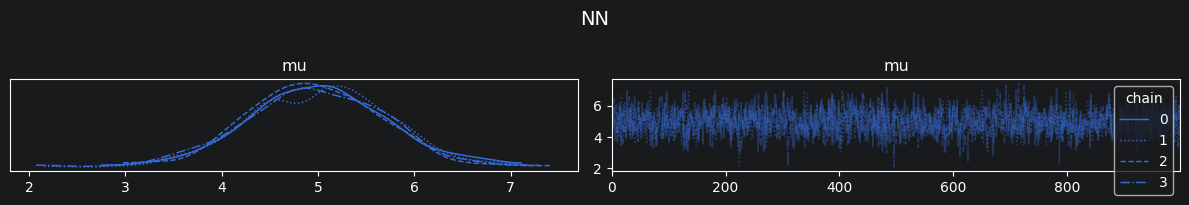

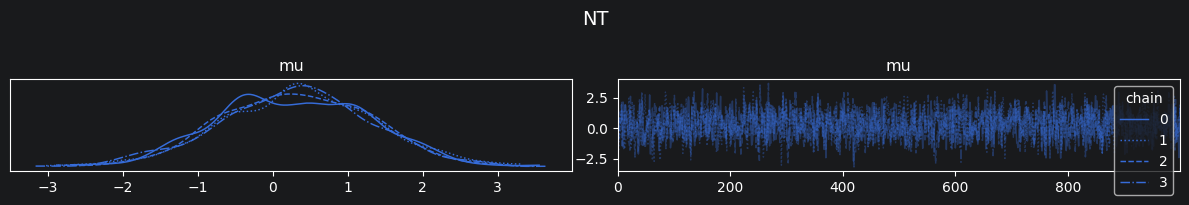

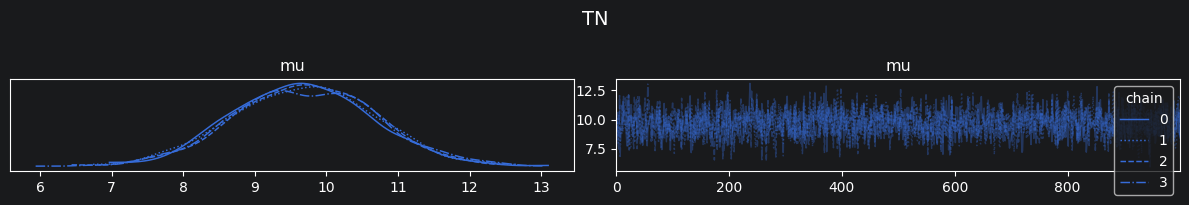

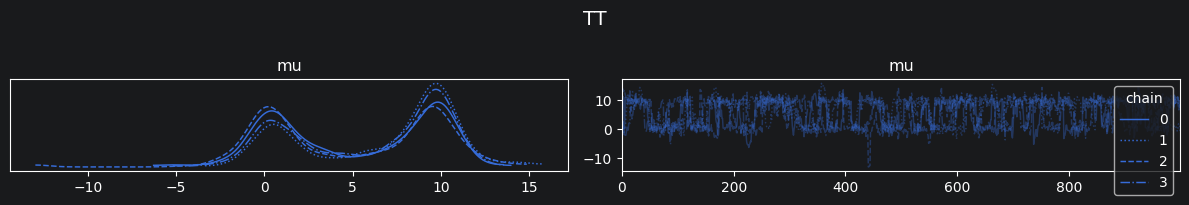

In [6]:
# Plot traces for each model
for model_name, posterior in results.items():
    plot_trace(posterior, title=model_name, legend=True)